# Exploratory Data Analysis — Synthetic Blast Damage Dataset

This notebook explores `blast_damage_dataset.csv`, generated from Kingery-Bulmash
style overpressure/impulse calculations combined with Pressure-Impulse (P-I)
damage curves for four structure types.

Goals of this EDA:
1. Understand the shape and quality of the data
2. Check class balance for `damage_category`
3. Visualize how overpressure, impulse, and scaled distance relate to damage
4. Sanity-check that the physics makes sense (closer/bigger charge -> more damage)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/blast_damage_dataset.csv")
df.head()

,charge_weight_kg,standoff_distance_m,scaled_distance_Z,structure_type,quality_factor,peak_overpressure_kpa,impulse_kpa_ms,damage_category
0,306.765,10.230,1.5168,masonry_wall,1.113,516.217,57.764,severe
1,275.830,64.381,9.8903,steel_frame,0.998,21.907,12.420,none
2,1089.515,30.308,2.9454,masonry_wall,1.056,162.273,55.001,severe
3,0.849,80.242,84.7467,steel_frame,0.994,7.476,0.500,none
4,1568.493,113.527,9.7710,rc_wall,0.958,24.923,21.540,none


## 1. Basic structure & data types

In [2]:
print(df.shape)
df.info()

(6000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   charge_weight_kg       6000 non-null   float64
 1   standoff_distance_m    6000 non-null   float64
 2   scaled_distance_Z      6000 non-null   float64
 3   structure_type         6000 non-null   str    
 4   quality_factor         6000 non-null   float64
 5   peak_overpressure_kpa  6000 non-null   float64
 6   impulse_kpa_ms         6000 non-null   float64
 7   damage_category        6000 non-null   str    
dtypes: float64(6), str(2)
memory usage: 375.1 KB


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
charge_weight_kg,6000.0,NaN,NaN,NaN,248.439926,432.476709,0.501,4.14875,34.796,277.61125,1999.619
standoff_distance_m,6000.0,NaN,NaN,NaN,37.238019,48.525961,1.0,3.6205,14.11,52.12425,199.981
scaled_distance_Z,6000.0,NaN,NaN,NaN,15.577824,28.113779,0.0874,1.152,4.3772,16.2945,225.7641
structure_type,6000,4,masonry_wall,1582,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_factor,6000.0,NaN,NaN,NaN,1.002043,0.117554,0.7,0.923,1.0,1.082,1.3
peak_overpressure_kpa,6000.0,NaN,NaN,NaN,1681.821143,3684.068523,5.962,12.9875,86.1885,1044.35125,19134.365
impulse_kpa_ms,6000.0,NaN,NaN,NaN,70.120587,147.241444,0.35,2.865,12.08,51.68225,1041.401
damage_category,6000,5,none,3257,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check for missing values
df.isnull().sum()

charge_weight_kg         0
standoff_distance_m      0
scaled_distance_Z        0
structure_type           0
quality_factor           0
peak_overpressure_kpa    0
impulse_kpa_ms           0
damage_category          0
dtype: int64

## 2. Class balance — damage category & structure type

/tmp/ipykernel_571/381620665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="damage_category", order=damage_order, ax=axes[0], palette="rocket")
/tmp/ipykernel_571/381620665.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="structure_type", ax=axes[1], palette="mako")


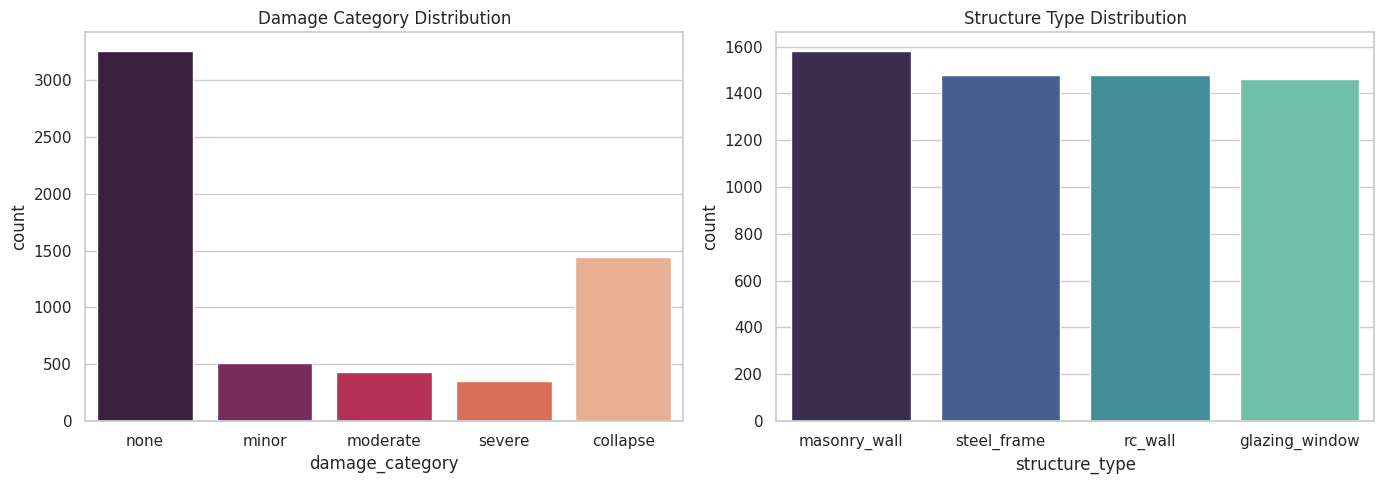

In [5]:
damage_order = ["none", "minor", "moderate", "severe", "collapse"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="damage_category", order=damage_order, ax=axes[0], palette="rocket")
axes[0].set_title("Damage Category Distribution")

sns.countplot(data=df, x="structure_type", ax=axes[1], palette="mako")
axes[1].set_title("Structure Type Distribution")

plt.tight_layout()
plt.show()

In [6]:
ct = pd.crosstab(df["structure_type"], df["damage_category"])
ct = ct[damage_order]
ct

damage_category,none,minor,moderate,severe,collapse
structure_type,,,,,
glazing_window,413,152,134,137,626
masonry_wall,882,113,142,92,353
rc_wall,1025,95,77,53,229
steel_frame,937,154,79,68,239


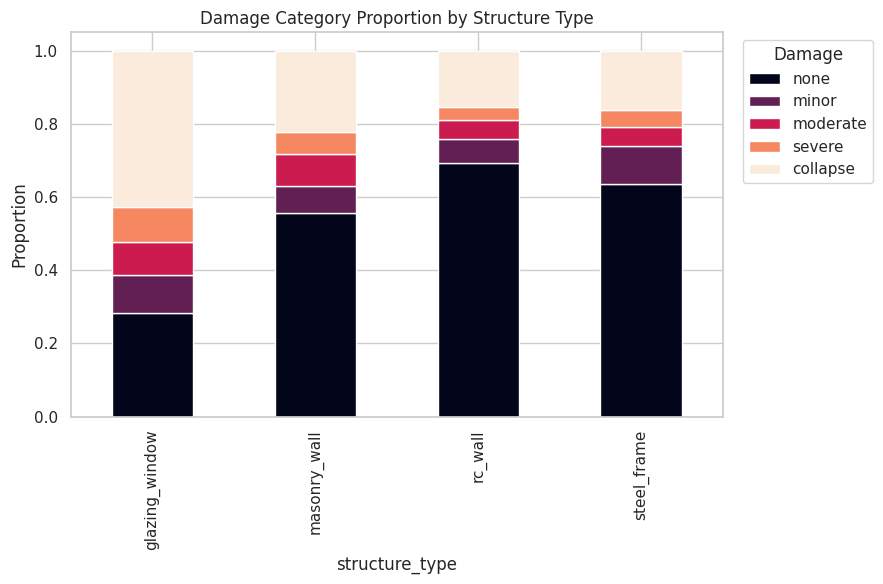

In [7]:
ct_norm = ct.div(ct.sum(axis=1), axis=0)

ct_norm.plot(kind="bar", stacked=True, figsize=(9, 6), colormap="rocket")
plt.title("Damage Category Proportion by Structure Type")
plt.ylabel("Proportion")
plt.legend(title="Damage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Note on class imbalance:** `none` and `collapse` dominate while
`minor`/`moderate`/`severe` are comparatively rare. This comes from
log-uniform sampling of charge weight and standoff distance — most
random combinations land either "too far/small to matter" or "close/large
enough to be catastrophic." This is realistic for blast data but means the
model training notebook will need to account for imbalance (e.g. class
weights, stratified splits, or resampling).

## 3. Numeric feature distributions

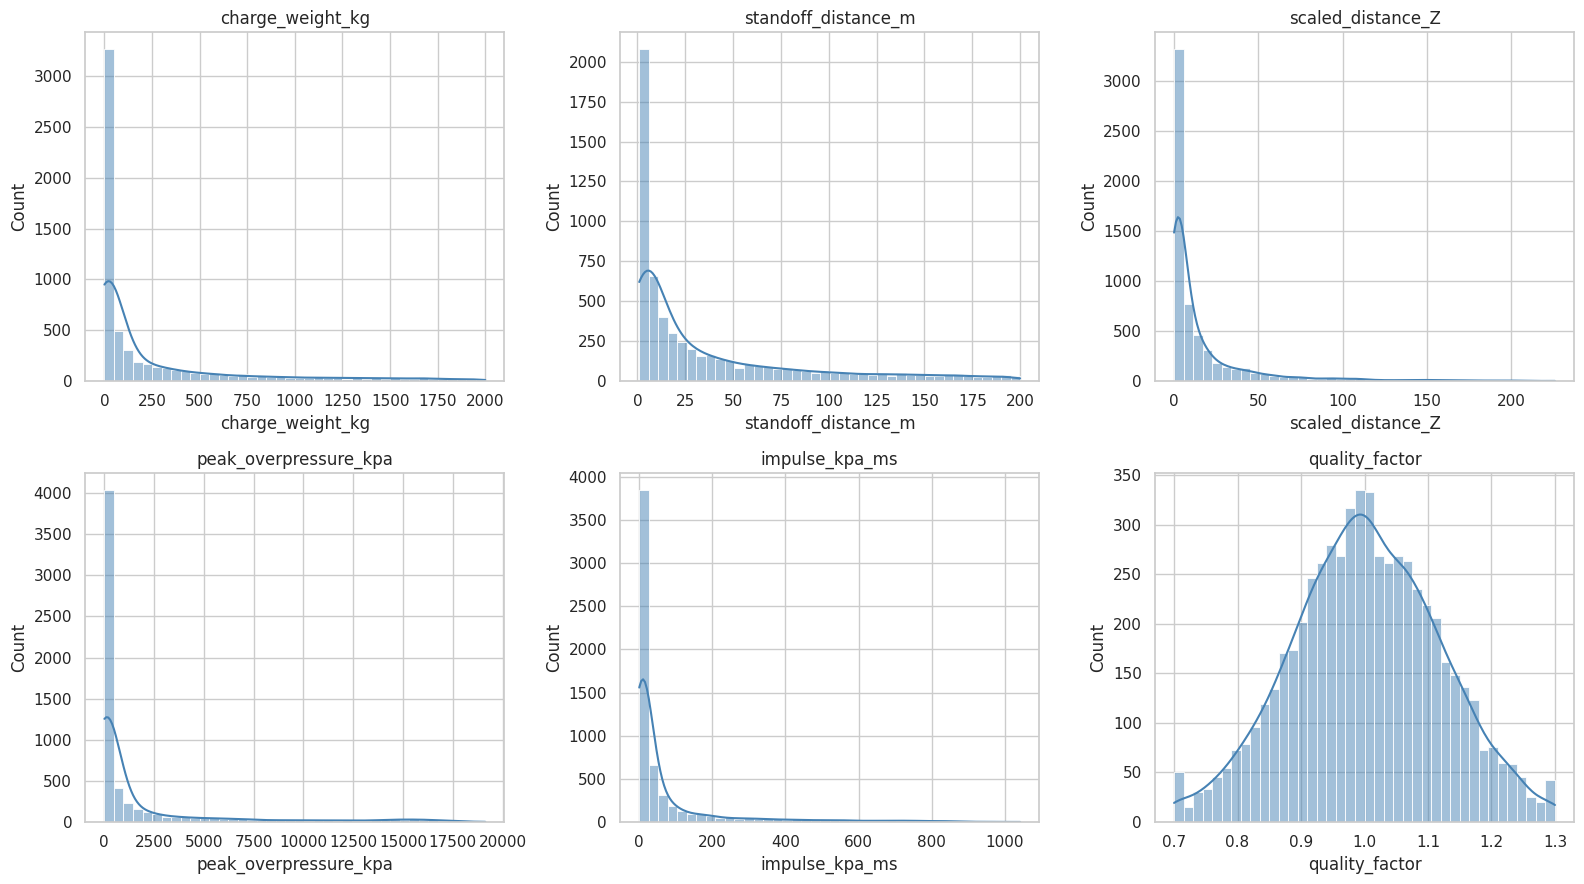

In [8]:
numeric_cols = ["charge_weight_kg", "standoff_distance_m", "scaled_distance_Z",
                "peak_overpressure_kpa", "impulse_kpa_ms", "quality_factor"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Charge weight, standoff distance, overpressure, and impulse are all heavily
right-skewed (as expected from log-uniform sampling + power-law physics).
Log-transforming these before feeding them to a model is worth trying,
especially for models sensitive to feature scale.

## 4. Relationship between scaled distance and damage

/tmp/ipykernel_571/3167753975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="damage_category", y="scaled_distance_Z", order=damage_order,


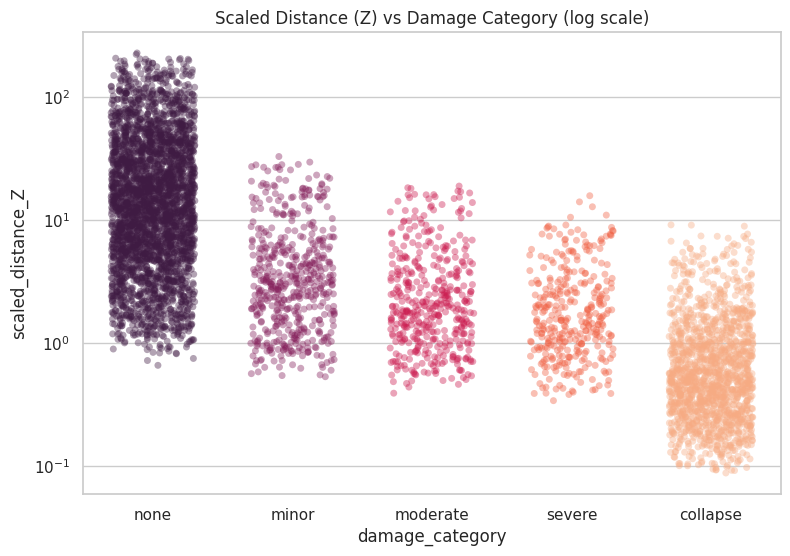

In [9]:
plt.figure(figsize=(9, 6))
sns.stripplot(data=df, x="damage_category", y="scaled_distance_Z", order=damage_order,
              jitter=0.3, alpha=0.4, palette="rocket")
plt.yscale("log")
plt.title("Scaled Distance (Z) vs Damage Category (log scale)")
plt.show()

This is the key physics sanity check: smaller scaled distance (closer /
bigger charge) should correspond to worse damage. The plot should show
`collapse` clustered at low Z and `none` clustered at high Z, confirming the
P-I labeling logic behaved as intended.

## 5. Pressure-Impulse space, colored by damage category

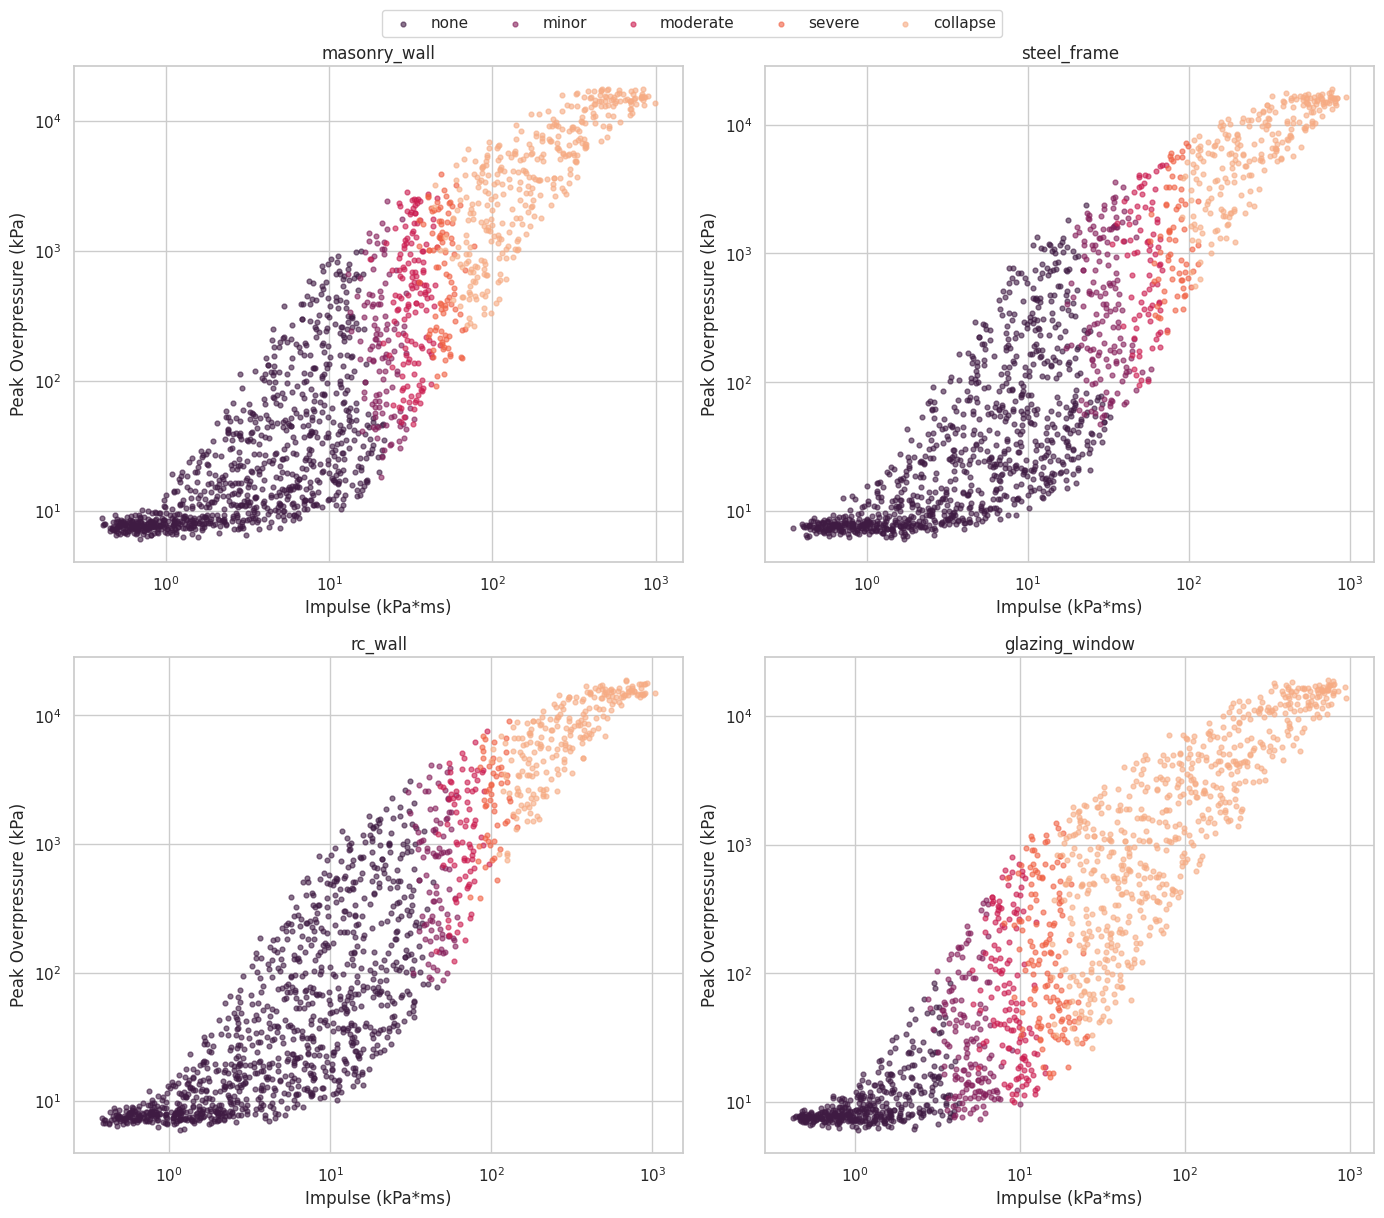

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
structure_types = df["structure_type"].unique()

palette = dict(zip(damage_order, sns.color_palette("rocket", len(damage_order))))

for ax, structure in zip(axes.flat, structure_types):
    sub = df[df["structure_type"] == structure]
    for damage in damage_order:
        pts = sub[sub["damage_category"] == damage]
        ax.scatter(pts["impulse_kpa_ms"], pts["peak_overpressure_kpa"],
                   s=12, alpha=0.6, label=damage, color=palette[damage])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Impulse (kPa*ms)")
    ax.set_ylabel("Peak Overpressure (kPa)")
    ax.set_title(structure)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

This is the classic P-I diagram view. You should see roughly nested
"bands" of color moving from bottom-left (none) to top-right (collapse) for
each structure type — this is exactly the shape a real P-I diagram takes,
which confirms the synthetic labeling logic is physically sensible.

## 6. Correlation between numeric features

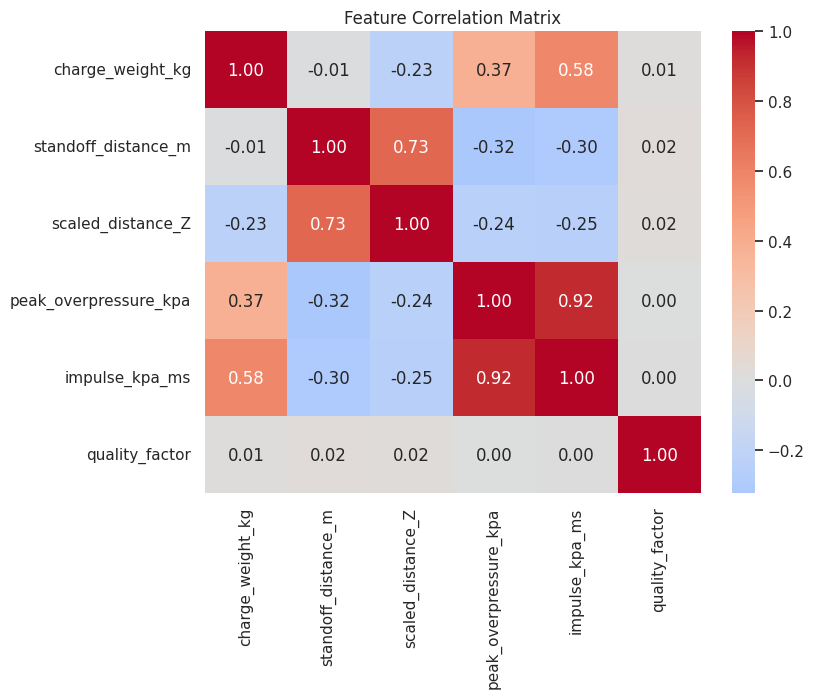

In [11]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

**Expect:** `charge_weight_kg` and `standoff_distance_m` both feed into
`scaled_distance_Z`, which strongly drives `peak_overpressure_kpa` and
`impulse_kpa_ms` — so those four should be correlated. `quality_factor` is
independent noise and should show near-zero correlation with everything,
which is a good check that it's behaving as intended (construction
variability, not a physics variable).

## 7. Summary / takeaways for modeling

- Dataset: 6000 synthetic samples, 4 structure types, 5 damage categories
- **Class imbalance** exists (`none` and `collapse` dominate) — use
  `class_weight="balanced"`, stratified train/test splits, and look at
  per-class F1/recall rather than just accuracy
- `scaled_distance_Z` (and by extension `peak_overpressure_kpa` /
  `impulse_kpa_ms`) is the dominant physical driver of damage — a model
  that doesn't pick up on this as the top feature importance is a red flag
- `structure_type` should meaningfully shift the damage thresholds, so it's
  worth checking model performance broken down per structure type, not just
  in aggregate
- Numeric features are right-skewed — log-transforming
  `charge_weight_kg`, `standoff_distance_m`, `peak_overpressure_kpa`, and
  `impulse_kpa_ms` before modeling is worth testing

Next: `02_model_training.ipynb`
